# Notebook 06 — SHAP Case Studies & Carbon/Energy Loss Quantification

**Paper**: *An Explainable, Data-Efficient Framework for Multi-Class Fault Diagnosis and Carbon-Loss Quantification in Early-Stage Solar PV Monitoring*

This notebook supports:
- **Section IV-E** — XAI root-cause attribution (SHAP for anomaly detection)
- **Section IV-F** — Carbon & energy loss quantification
- **Section VI** — Results & Discussion (inverter case studies)

---

In [1]:
# === Setup ===
import sys, os, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.preprocessing import StandardScaler

from scripts.paper.data_loader import PLANT1_ID, PLANT2_ID, EMISSION_FACTOR, INTERVAL_HOURS
from scripts.paper.anomaly_taxonomy import apply_taxonomy, CLASS_DESCRIPTIONS
from scripts.paper.plot_utils import (
    set_paper_style, save_fig, COLORS, ANOMALY_COLORS,
    dual_column_figsize, single_column_figsize, format_thousands
)

set_paper_style()
print('Setup complete.')

Setup complete.


In [2]:
# Load datasets from previous notebooks
df = pd.read_csv(os.path.join(PROJECT_ROOT, 'data', 'processed', 'paper', 'paper_dataset.csv'))
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
df['DATE'] = pd.to_datetime(df['DATE'])

# Apply taxonomy if not already done
if 'ANOMALY_CLASS' not in df.columns:
    df = apply_taxonomy(df)

# Load anomaly baseline results
ad_path = os.path.join(PROJECT_ROOT, 'data', 'processed', 'paper', 'anomaly_baseline_results.csv')
if os.path.exists(ad_path):
    ad_results = pd.read_csv(ad_path)
    ad_results['DATE_TIME'] = pd.to_datetime(ad_results['DATE_TIME'])
    print(f'Anomaly results loaded: {ad_results.shape}')
else:
    print('Warning: anomaly_baseline_results.csv not found. Run Notebook 05 first.')
    ad_results = None

print(f'Paper dataset shape: {df.shape}')

Anomaly results loaded: (77098, 16)
Paper dataset shape: (136476, 35)


## 1. SHAP for Anomaly Detection

We train a **supervised XGBoost Classifier** using the rule-based anomaly labels as proxy targets, then apply SHAP to explain **why** each record is classified as anomalous. This connects the multi-class taxonomy to feature-level explanations.

In [3]:
# === Train XGBoost Classifier for anomaly explanation ===

AD_FEATURES = [
    'AC_POWER', 'DC_POWER_CORRECTED', 'EFFICIENCY_CORRECTED',
    'IRRADIATION', 'MODULE_TEMPERATURE', 'HOUR_SIN', 'HOUR_COS',
    'POWER_GAP_PERCENT'
]

# Daytime data with taxonomy labels
day = df[(df['IS_DAY'] == True)].dropna(subset=AD_FEATURES).copy()

X_ad = day[AD_FEATURES]
y_ad = day['ANOMALY_BINARY']  # Binary for SHAP

# Train supervised classifier
ad_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss',
)
ad_clf.fit(X_ad, y_ad)

print(f'Classifier trained on {len(X_ad):,} records')
print(f'Train accuracy: {ad_clf.score(X_ad, y_ad):.4f}')

Classifier trained on 77,098 records
Train accuracy: 1.0000


In [4]:
# === SHAP for anomaly classifier ===

shap_sample = X_ad.sample(min(1500, len(X_ad)), random_state=42)
explainer_ad = shap.TreeExplainer(ad_clf)
shap_values_ad = explainer_ad.shap_values(shap_sample)

print(f'SHAP values shape: {shap_values_ad.shape}')

SHAP values shape: (1500, 8)


  → Saved: D:\Aptech\Du_an\reports\figures\paper\fig_09_shap_anomaly_importance.png


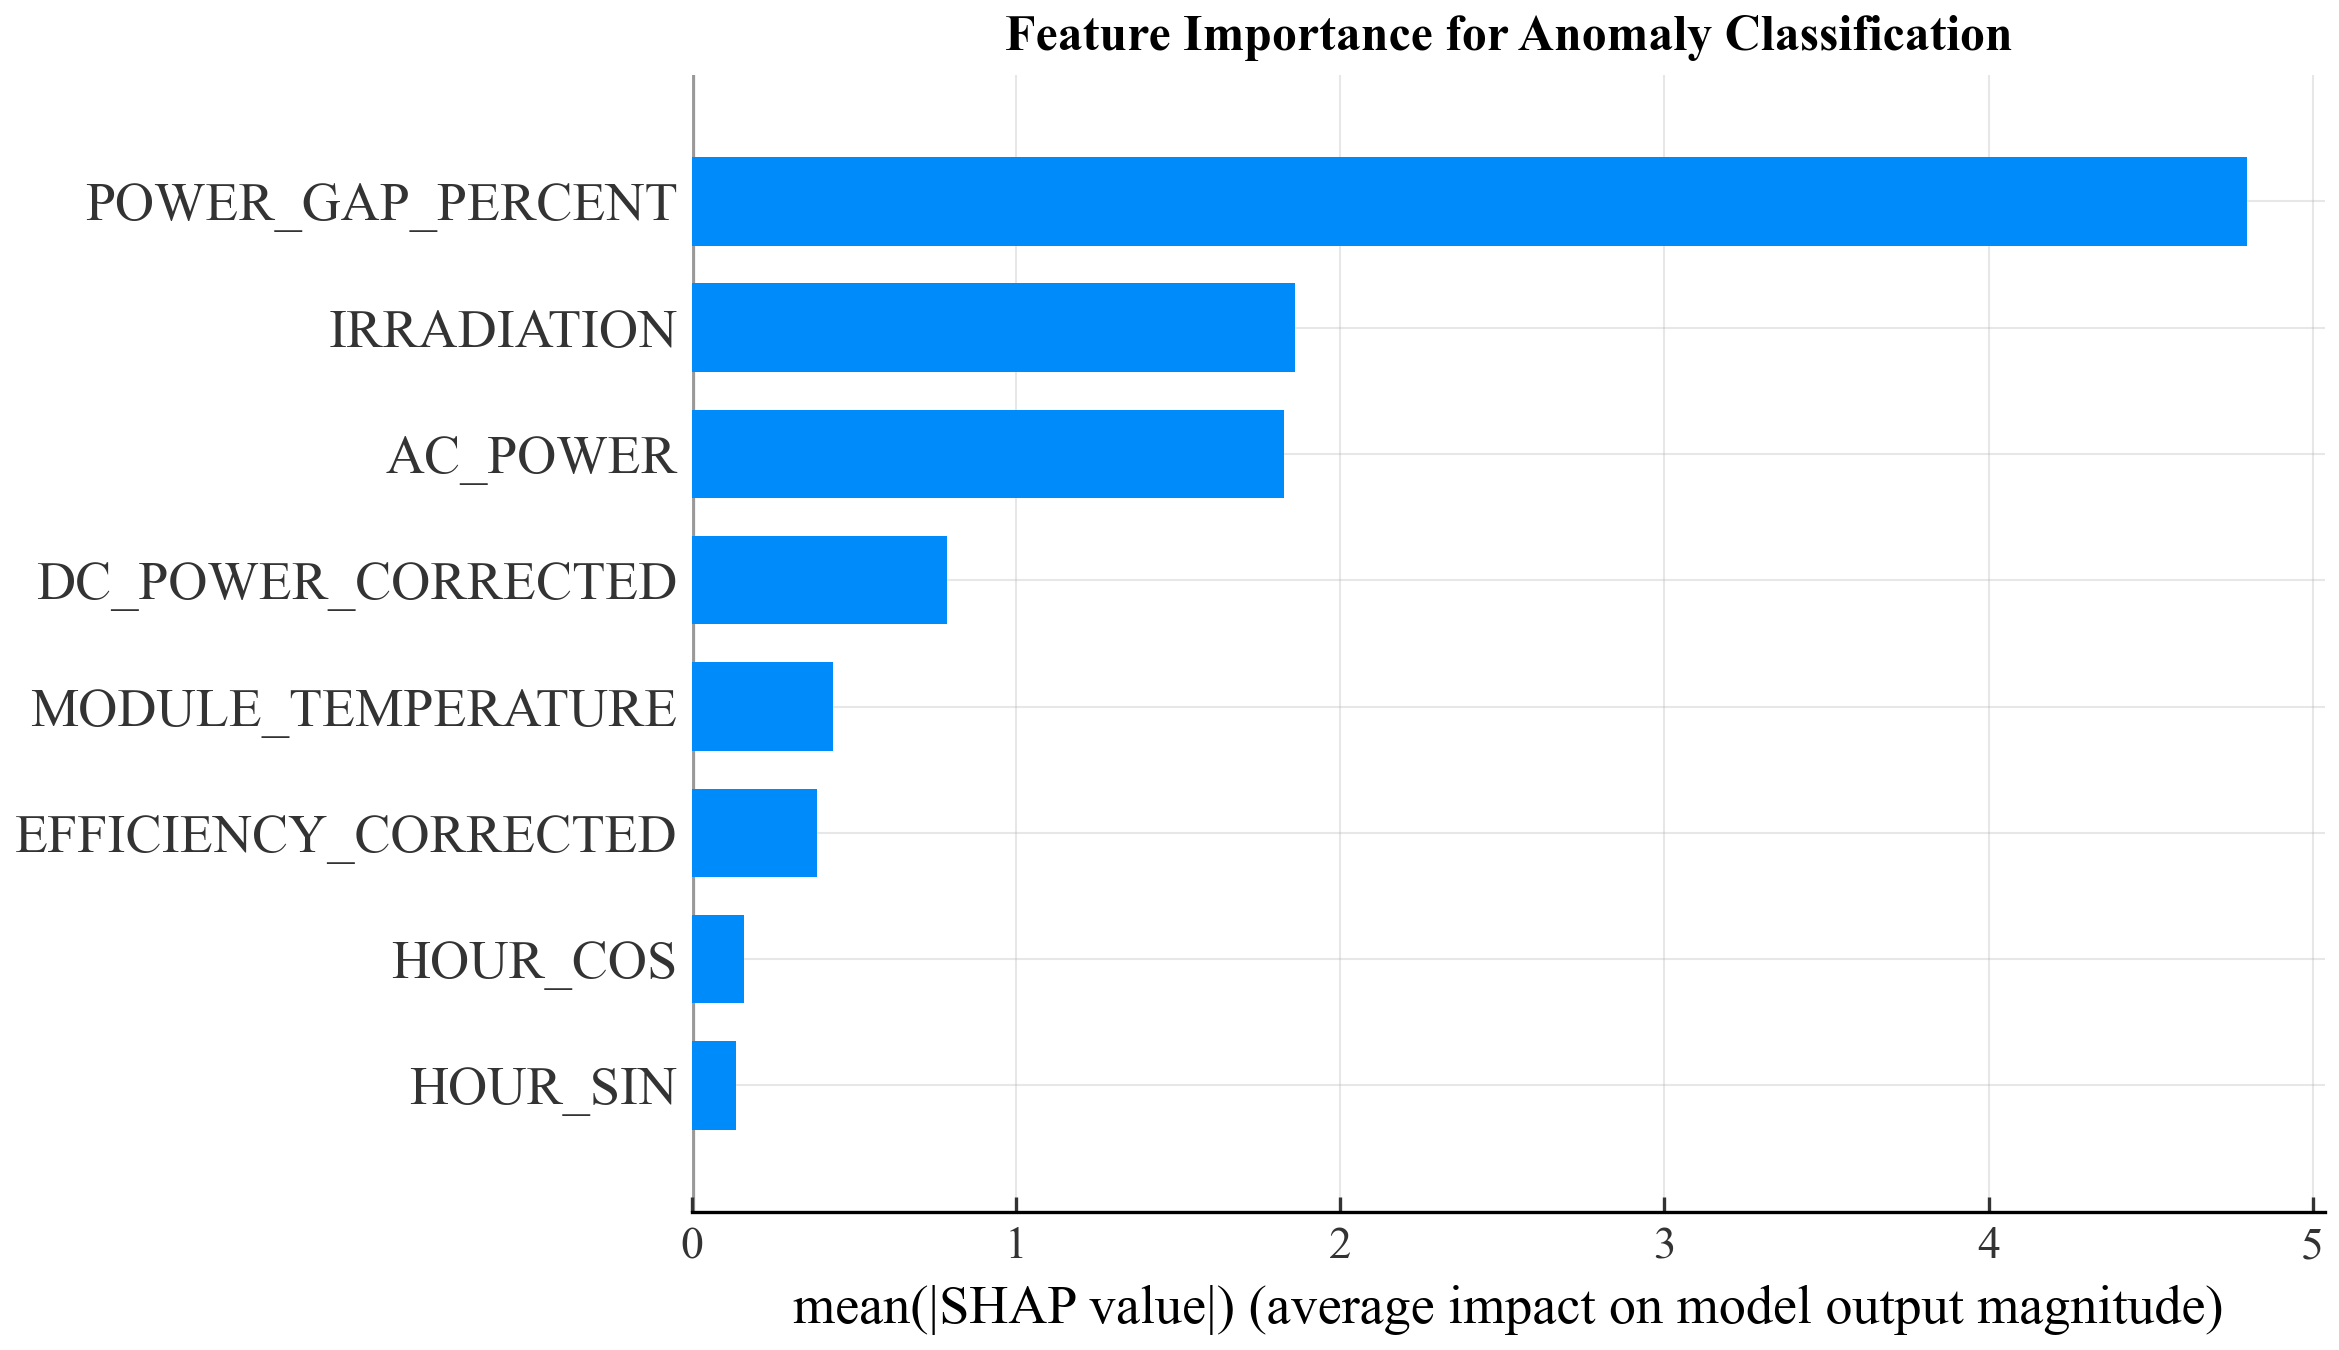

In [5]:
# === Fig 9: SHAP Feature Importance for Anomaly Detection ===

fig, ax = plt.subplots(figsize=single_column_figsize(3.5))
shap.summary_plot(shap_values_ad, shap_sample, plot_type='bar', show=False,
                  feature_names=AD_FEATURES)
plt.title('Feature Importance for Anomaly Classification', fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig(plt.gcf(), 'fig_09_shap_anomaly_importance')
plt.show()

  → Saved: D:\Aptech\Du_an\reports\figures\paper\fig_10_shap_anomaly_beeswarm.png


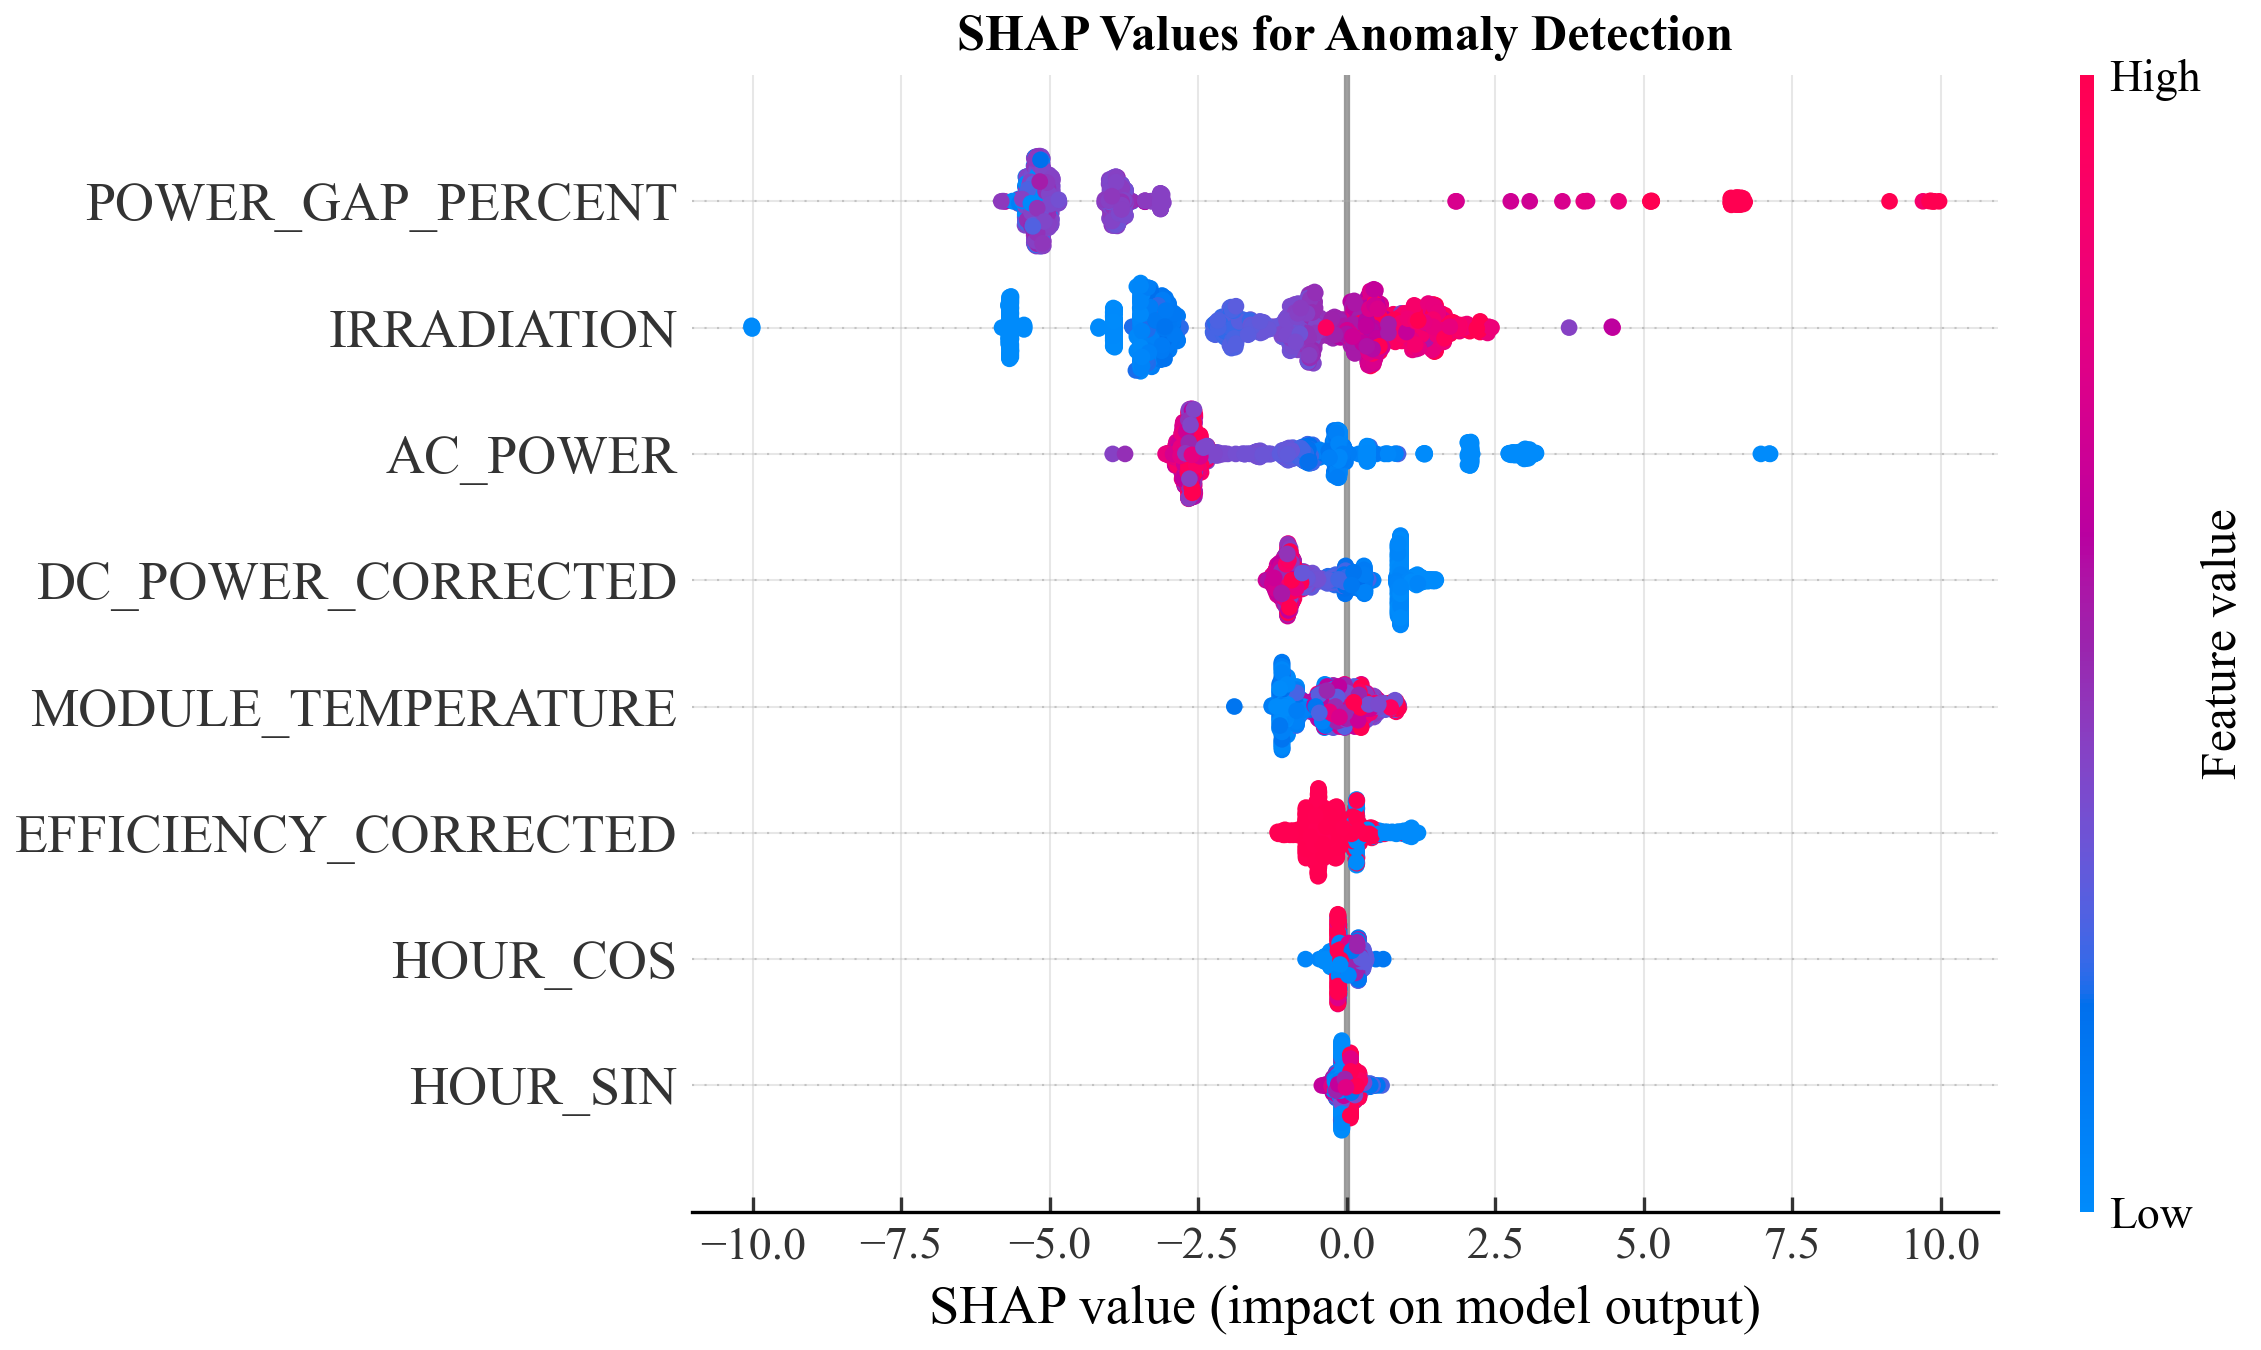

In [6]:
# === Fig 10: SHAP Beeswarm for Anomaly ===

fig, ax = plt.subplots(figsize=single_column_figsize(3.5))
shap.summary_plot(shap_values_ad, shap_sample, show=False,
                  feature_names=AD_FEATURES)
plt.title('SHAP Values for Anomaly Detection', fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig(plt.gcf(), 'fig_10_shap_anomaly_beeswarm')
plt.show()

## 2. Inverter Case Studies

We present detailed case studies for 3 inverters to demonstrate the framework's diagnostic capability:

1. **`bvBOhCH3iADSZry`** (Plant 1) — Known underperformer
2. **Worst inverter in Plant 2** — Auto-selected by highest anomaly count
3. **A healthy inverter** — Control comparison

In [7]:
# === Identify case study inverters ===

TARGET_INVERTER = 'bvBOhCH3iADSZry'

# Worst Plant 2 inverter (highest anomaly rate)
p2_day = day[day['PLANT_ID'] == PLANT2_ID]
p2_anomaly_rate = p2_day.groupby('SOURCE_KEY')['ANOMALY_BINARY'].mean().sort_values(ascending=False)
WORST_P2_INVERTER = p2_anomaly_rate.index[0]

# Healthy inverter (lowest anomaly rate in Plant 1, excluding target)
p1_day = day[(day['PLANT_ID'] == PLANT1_ID) & (day['SOURCE_KEY'] != TARGET_INVERTER)]
p1_anomaly_rate = p1_day.groupby('SOURCE_KEY')['ANOMALY_BINARY'].mean().sort_values(ascending=True)
HEALTHY_INVERTER = p1_anomaly_rate.index[0]

print(f'Case Study Inverters:')
print(f'  1. Target (Plant 1): {TARGET_INVERTER} — anomaly rate: {day[day["SOURCE_KEY"]==TARGET_INVERTER]["ANOMALY_BINARY"].mean()*100:.1f}%')
print(f'  2. Worst (Plant 2):  {WORST_P2_INVERTER} — anomaly rate: {p2_anomaly_rate.iloc[0]*100:.1f}%')
print(f'  3. Healthy (Plant 1): {HEALTHY_INVERTER} — anomaly rate: {p1_anomaly_rate.iloc[0]*100:.1f}%')

Case Study Inverters:
  1. Target (Plant 1): bvBOhCH3iADSZry — anomaly rate: 1.4%
  2. Worst (Plant 2):  Et9kgGMDl729KT4 — anomaly rate: 18.6%
  3. Healthy (Plant 1): 1IF53ai7Xc0U56Y — anomaly rate: 0.0%


In [8]:
# === Helper: Case study visualization ===

def plot_case_study(df_inv, inverter_name, plant_name, fig_prefix, explainer, features):
    """
    Generate case study figures for a specific inverter:
    (a) Actual vs Expected AC Power timeline
    (b) SHAP waterfall for worst anomalous timestamp
    """

    # --- (a) Actual vs Expected Timeline ---
    fig, axes = plt.subplots(2, 1, figsize=dual_column_figsize(5.0), gridspec_kw={'height_ratios': [3, 1]})

    ax = axes[0]
    ax.plot(df_inv['DATE_TIME'], df_inv['AC_POWER'], color=COLORS['primary'],
            linewidth=0.8, alpha=0.8, label='Actual AC Power')
    if 'EXPECTED_AC_POWER' in df_inv.columns:
        ax.plot(df_inv['DATE_TIME'], df_inv['EXPECTED_AC_POWER'], color=COLORS['expected'],
                linewidth=0.8, alpha=0.6, linestyle='--', label='Expected AC Power')

    # Highlight anomalies
    if 'ANOMALY_CLASS' in df_inv.columns:
        for cls in ['TOTAL_LOSS', 'PARTIAL_LOSS', 'THERMAL_DEGRADE']:
            mask = df_inv['ANOMALY_CLASS'] == cls
            if mask.any():
                ax.scatter(df_inv.loc[mask, 'DATE_TIME'], df_inv.loc[mask, 'AC_POWER'],
                          s=8, color=ANOMALY_COLORS.get(cls, 'red'), alpha=0.7, label=cls, zorder=5)

    ax.set_ylabel('AC Power (kW)')
    ax.set_title(f'{plant_name} — Inverter {inverter_name}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right', ncol=2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    format_thousands(ax)

    # --- Power loss subplot ---
    ax2 = axes[1]
    if 'POWER_LOSS_KW' in df_inv.columns:
        ax2.fill_between(df_inv['DATE_TIME'], df_inv['POWER_LOSS_KW'],
                         color=COLORS['secondary'], alpha=0.4)
        ax2.set_ylabel('Power Loss (kW)')
    ax2.set_xlabel('Date')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))

    plt.tight_layout()
    save_fig(fig, f'{fig_prefix}_timeline')
    plt.show()

    # --- (b) SHAP Waterfall for worst anomalous timestamp ---
    anomalous = df_inv[df_inv['ANOMALY_BINARY'] == 1]
    if len(anomalous) > 0 and 'POWER_LOSS_KW' in anomalous.columns:
        worst_idx = anomalous['POWER_LOSS_KW'].idxmax()
        worst_row = df_inv.loc[[worst_idx], features]

        shap_vals = explainer.shap_values(worst_row)
        shap_exp = shap.Explanation(
            values=shap_vals[0],
            base_values=explainer.expected_value,
            data=worst_row.values[0],
            feature_names=features,
        )

        fig, ax = plt.subplots(figsize=single_column_figsize(3.5))
        shap.waterfall_plot(shap_exp, show=False)
        plt.title(f'SHAP Waterfall — Worst Anomaly ({inverter_name})', fontsize=11, fontweight='bold')
        plt.tight_layout()
        save_fig(plt.gcf(), f'{fig_prefix}_shap_waterfall')
        plt.show()
    else:
        pass


  → Saved: D:\Aptech\Du_an\reports\figures\paper\fig_11_case1_timeline.png


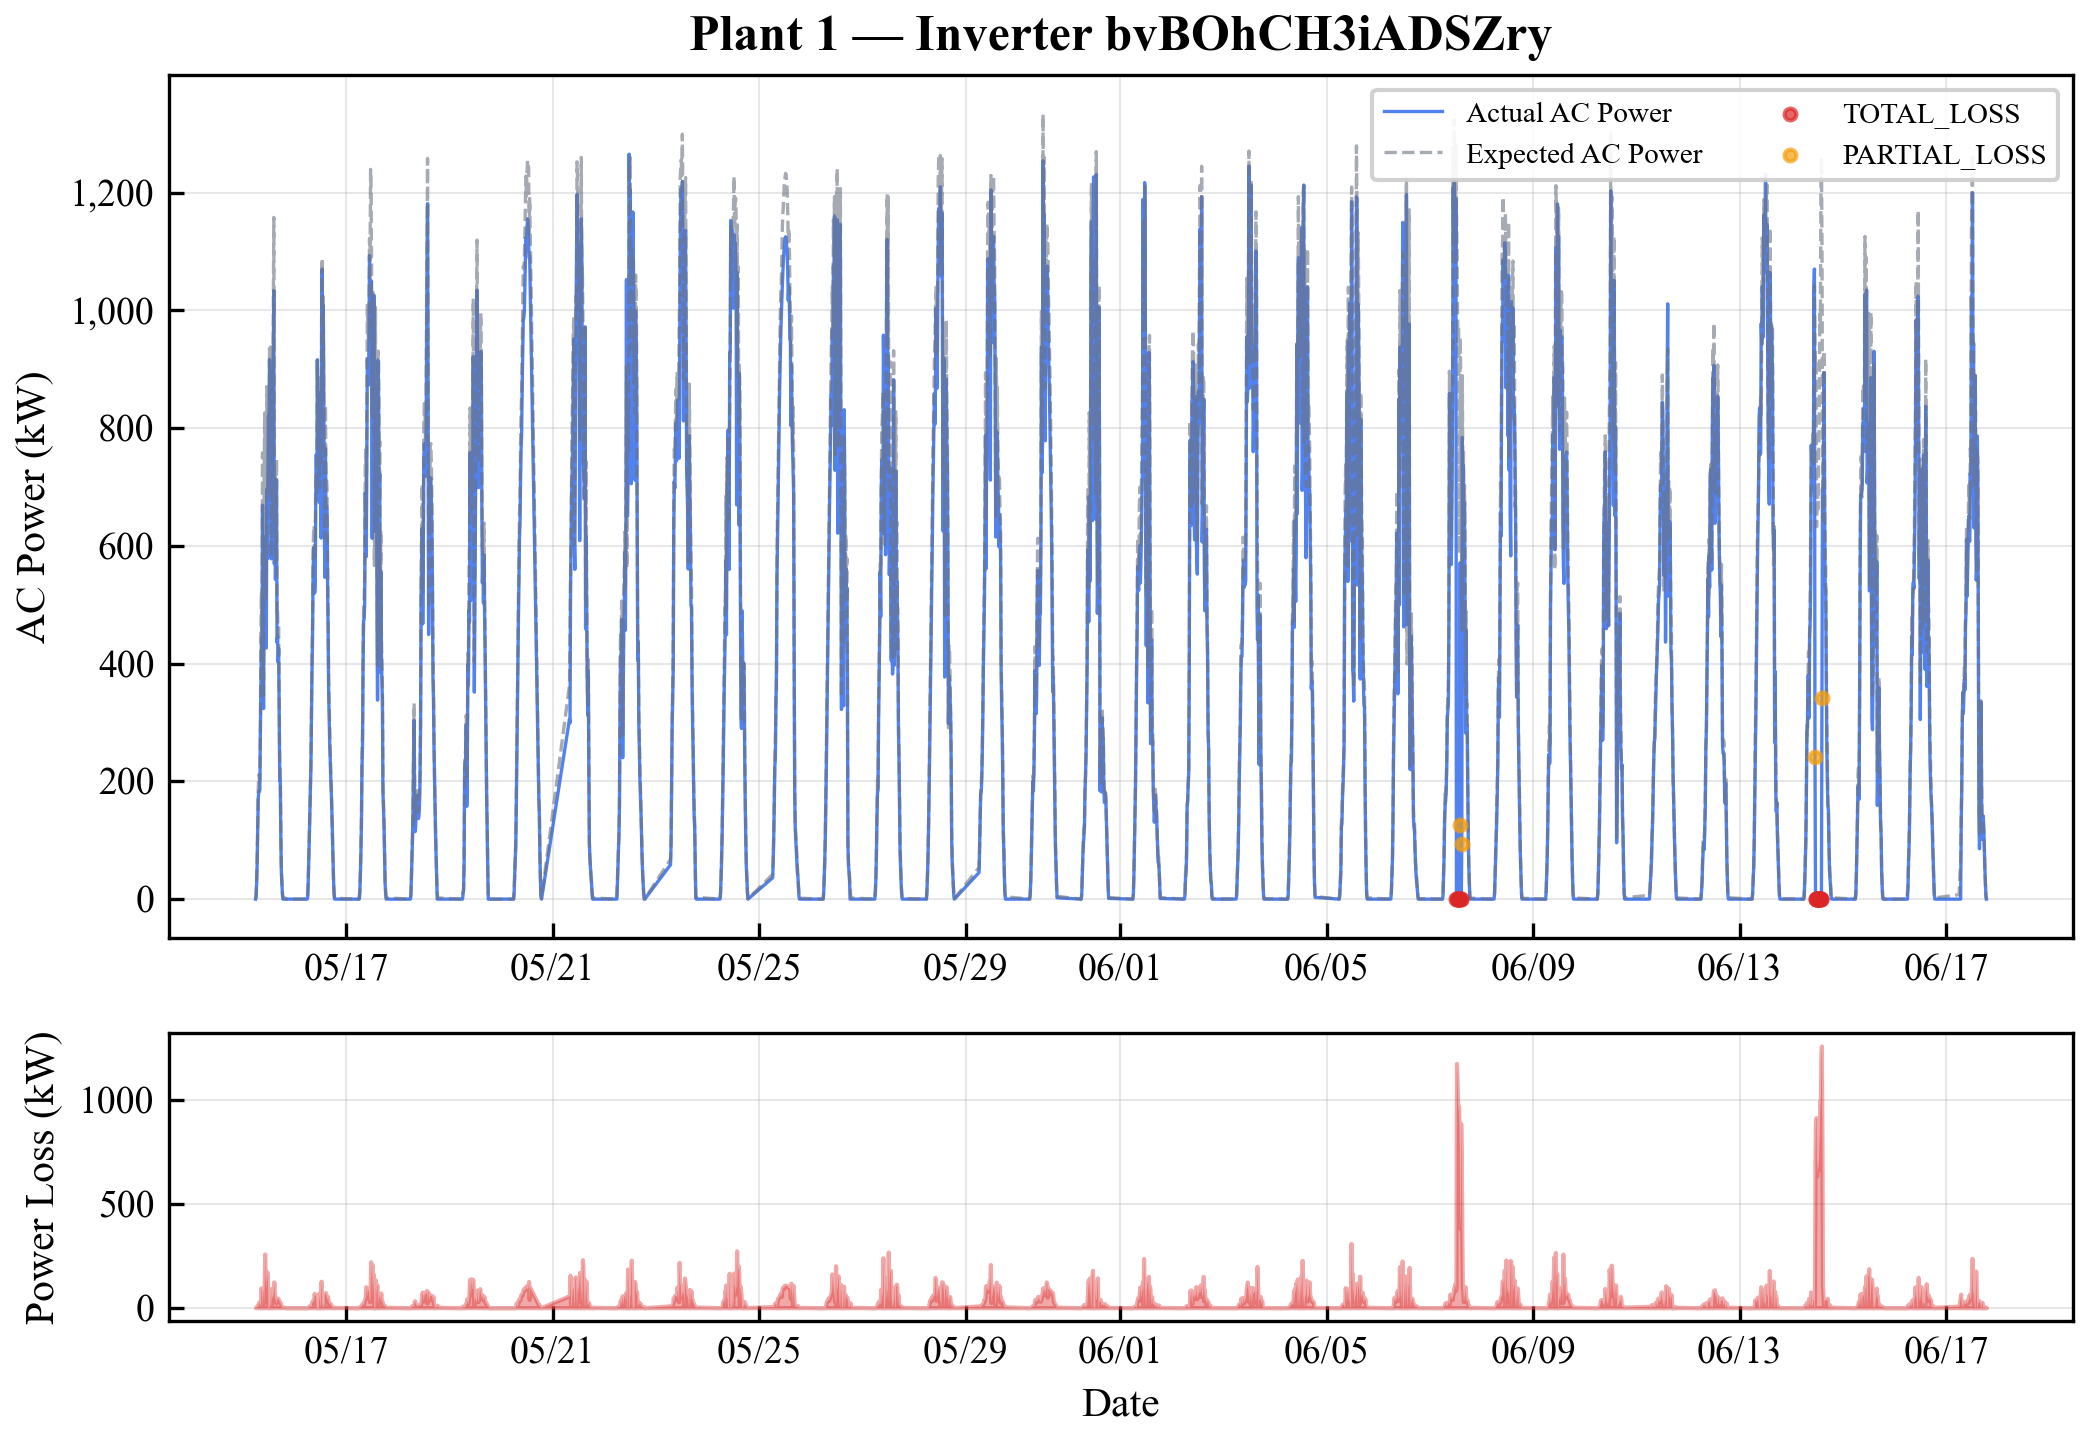

  → Saved: D:\Aptech\Du_an\reports\figures\paper\fig_11_case1_shap_waterfall.png


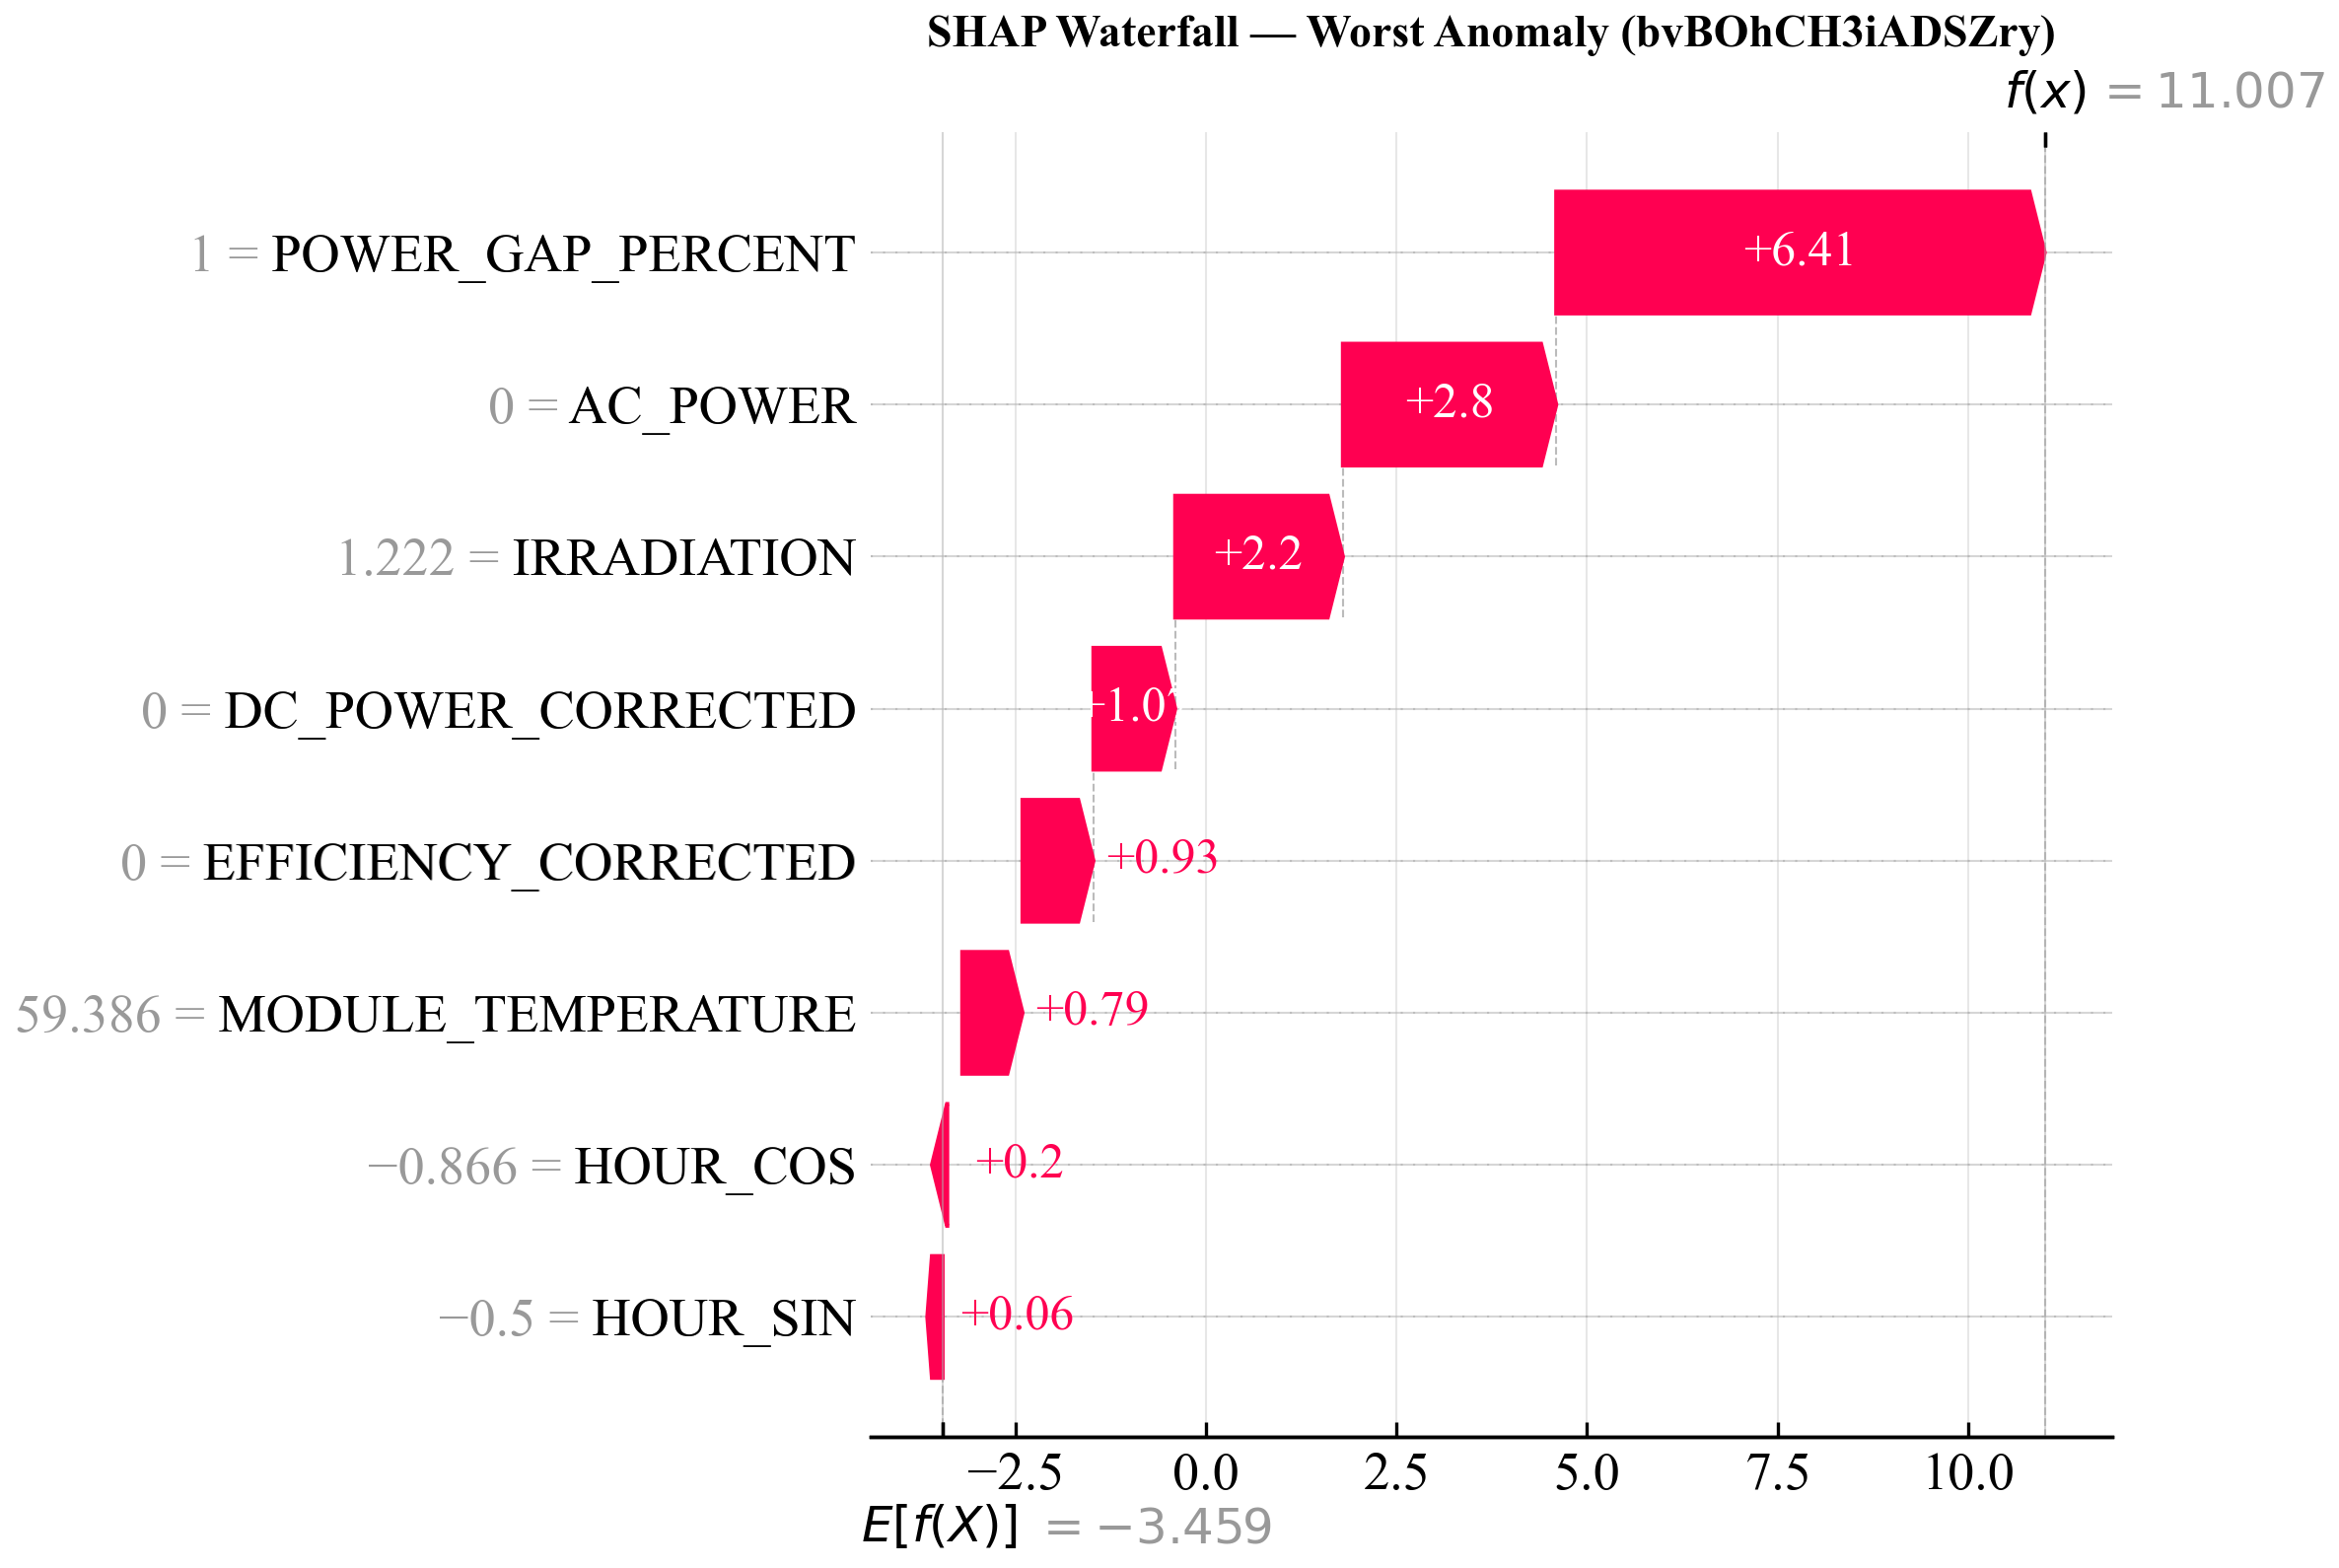

In [9]:
# === Apply Mask to remove Prediction Noise during NORMAL periods ===
day['TRUE_ENERGY_LOSS_KWH'] = np.where(day['ANOMALY_BINARY'] == 1, day['ENERGY_LOSS_KWH'], 0)
day['TRUE_CO2_LOSS_KG'] = np.where(day['ANOMALY_BINARY'] == 1, day['CO2_LOSS_KG'], 0)

# === Case Study 1: bvBOhCH3iADSZry (Plant 1, target underperformer) ===


inv1 = day[day['SOURCE_KEY'] == TARGET_INVERTER].sort_values('DATE_TIME')

plot_case_study(inv1, TARGET_INVERTER, 'Plant 1', 'fig_11_case1', explainer_ad, AD_FEATURES)

  → Saved: D:\Aptech\Du_an\reports\figures\paper\fig_12_case2_timeline.png


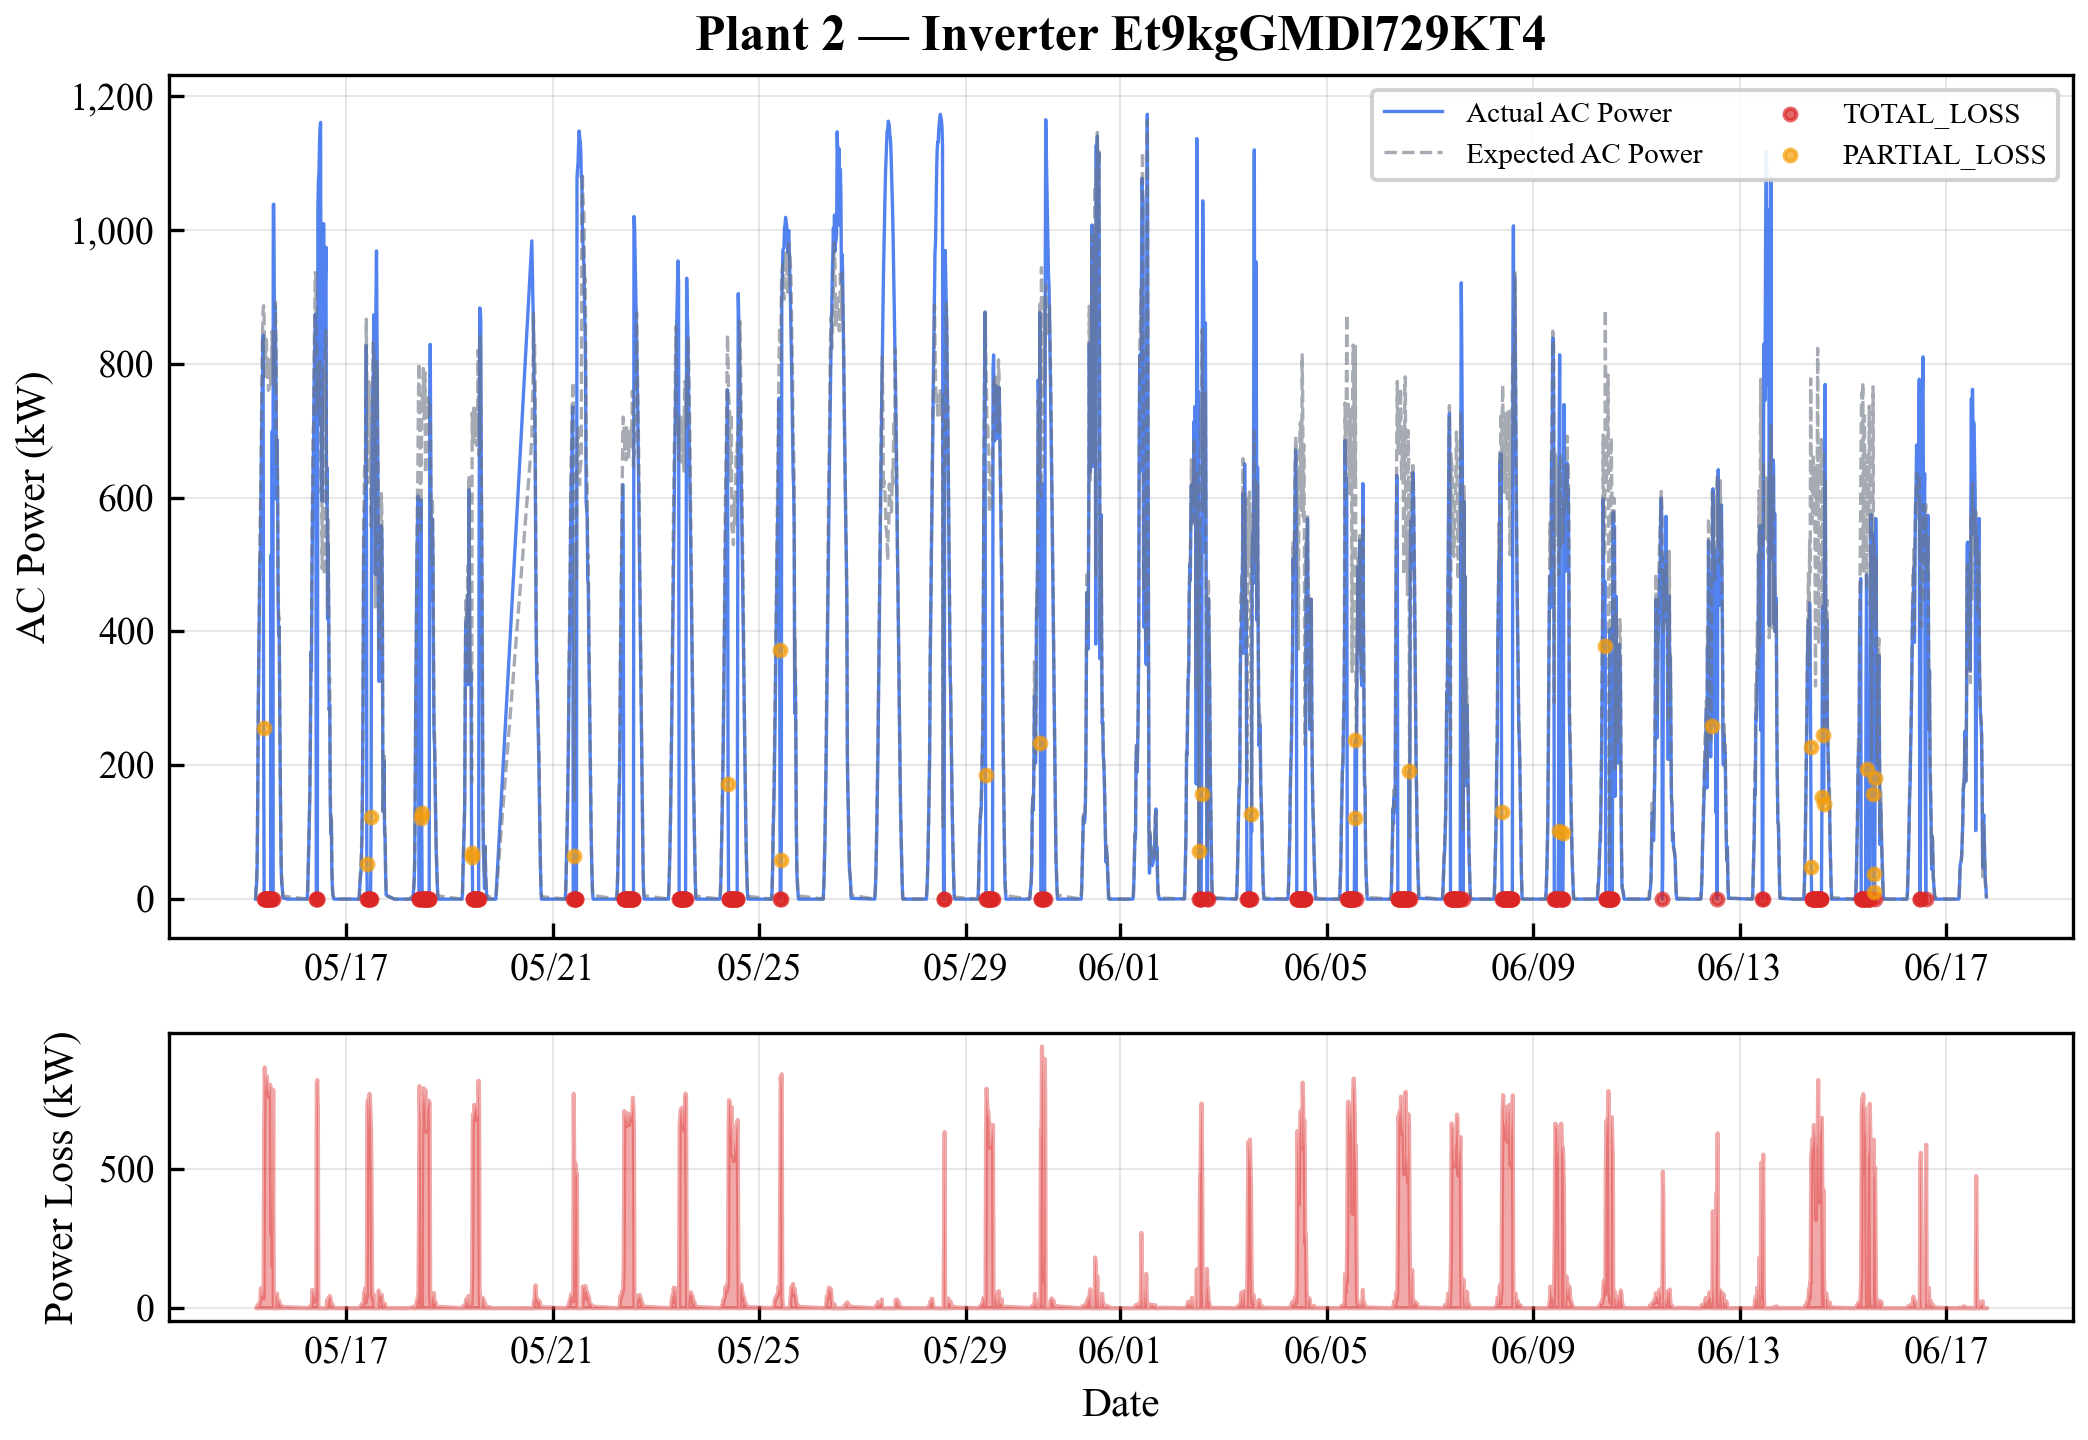

  → Saved: D:\Aptech\Du_an\reports\figures\paper\fig_12_case2_shap_waterfall.png


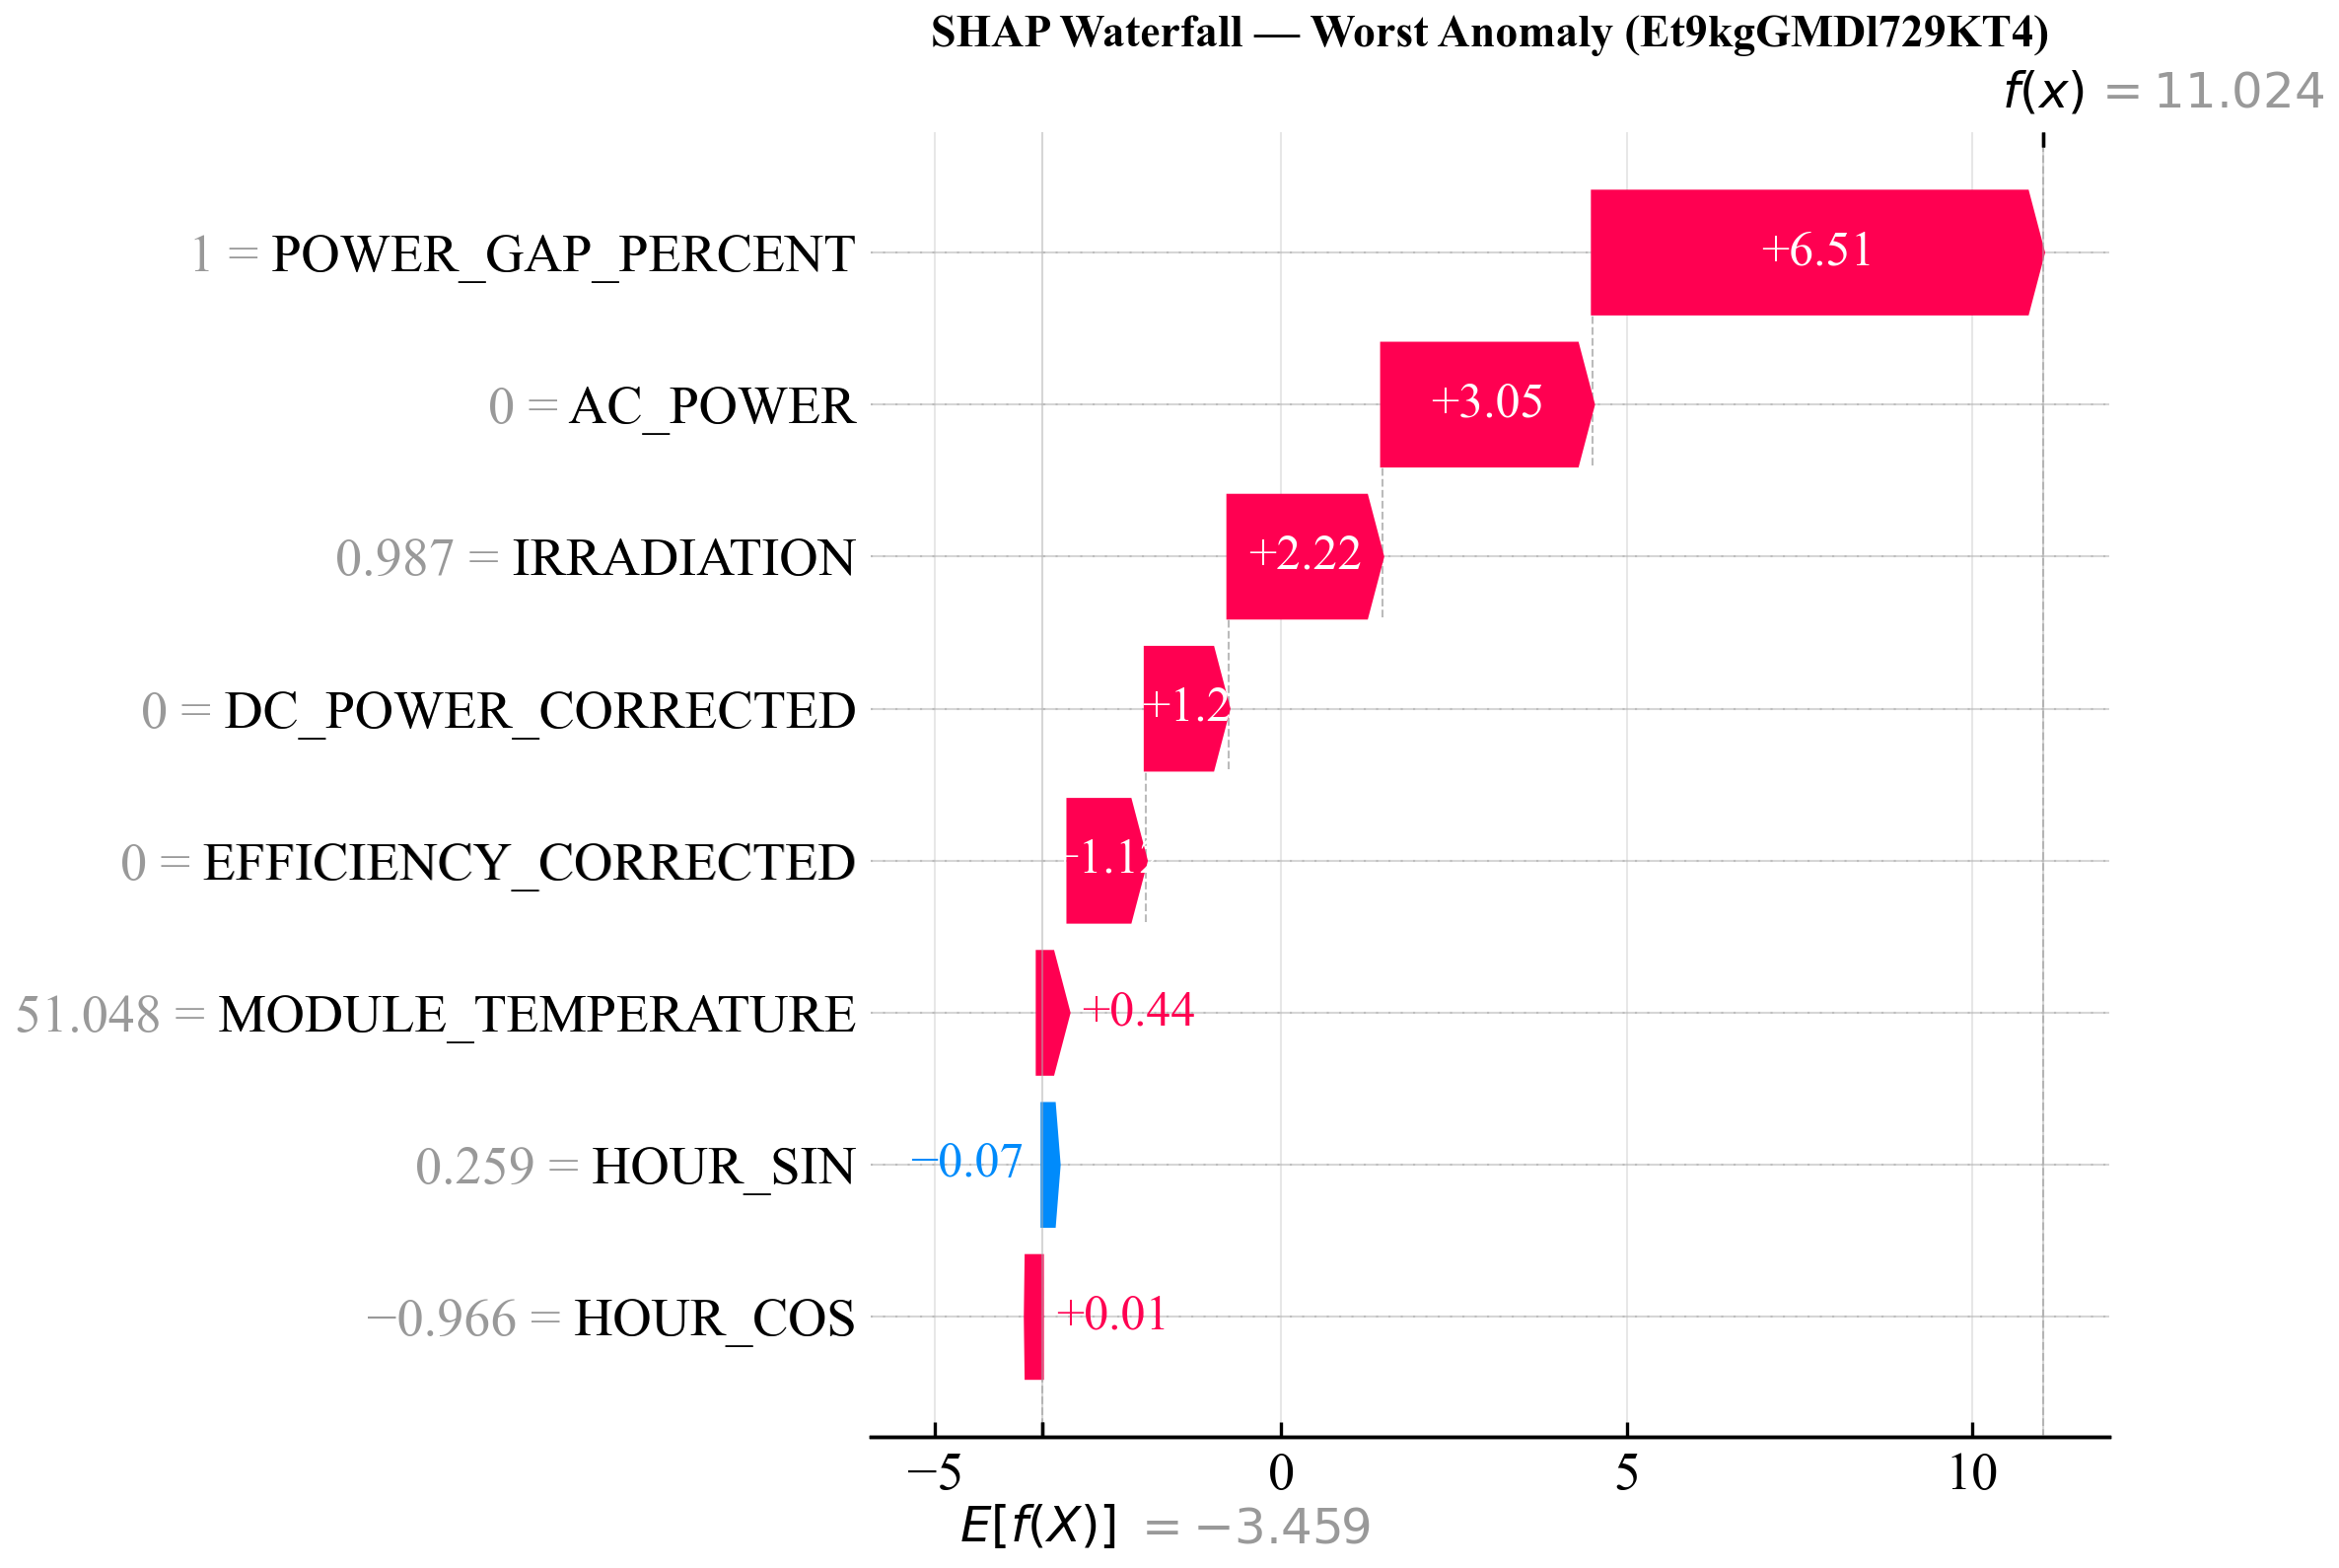

In [10]:
# === Case Study 2: Worst Plant 2 inverter ===


inv2 = day[day['SOURCE_KEY'] == WORST_P2_INVERTER].sort_values('DATE_TIME')

plot_case_study(inv2, WORST_P2_INVERTER, 'Plant 2', 'fig_12_case2', explainer_ad, AD_FEATURES)

  → Saved: D:\Aptech\Du_an\reports\figures\paper\fig_13_case3_timeline.png


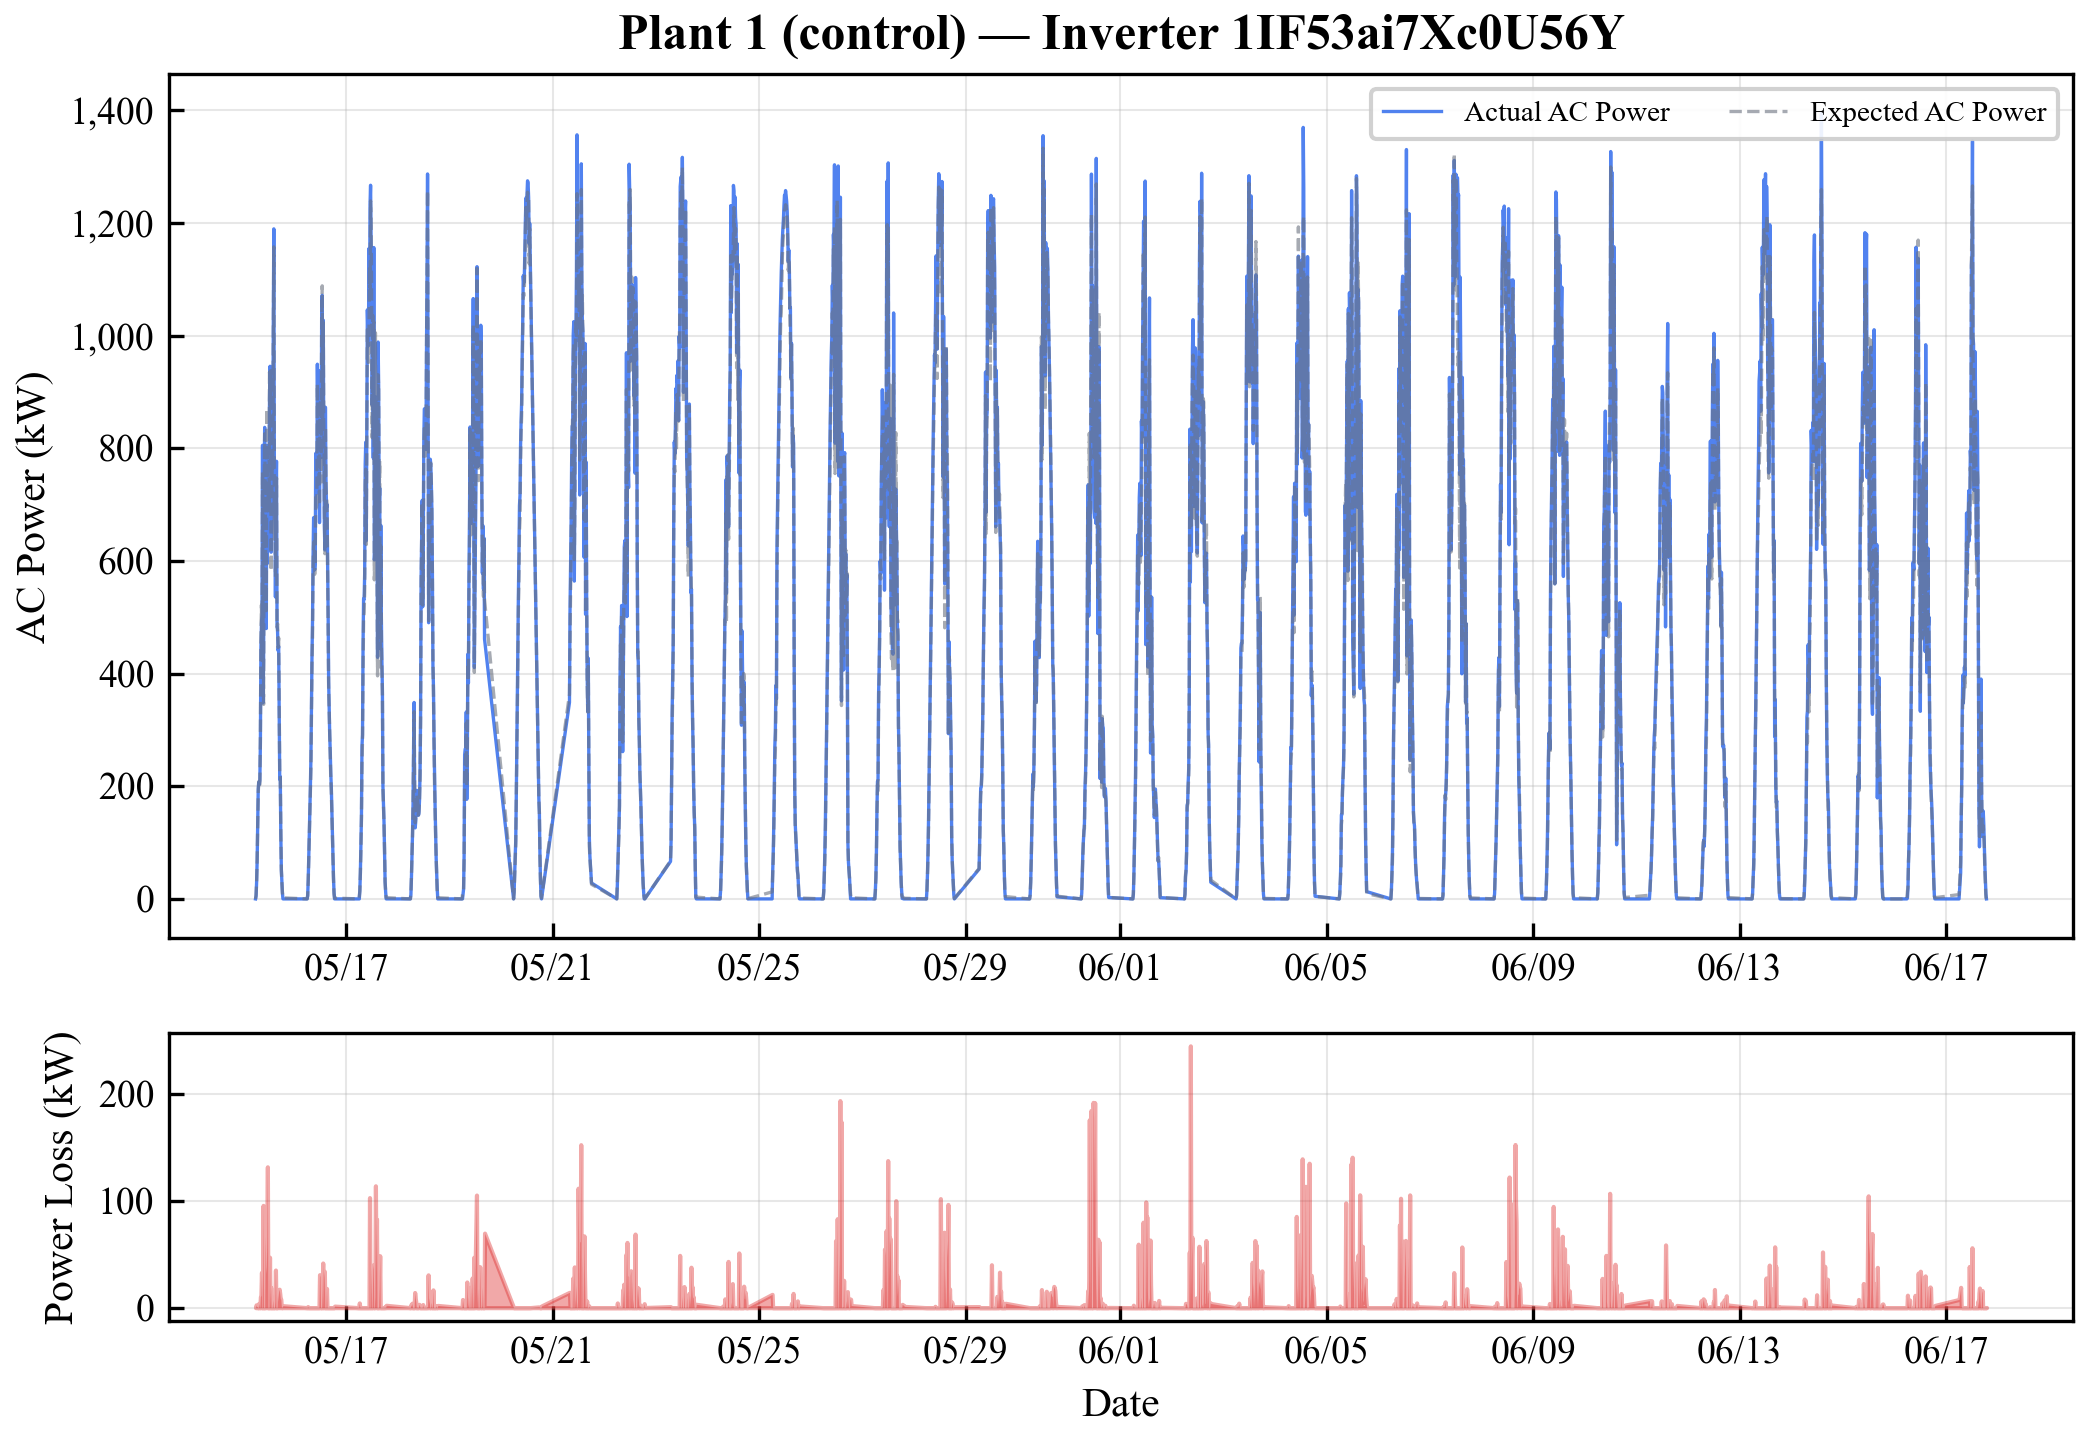

In [11]:
# === Case Study 3: Healthy Inverter (control) ===


inv3 = day[day['SOURCE_KEY'] == HEALTHY_INVERTER].sort_values('DATE_TIME')

plot_case_study(inv3, HEALTHY_INVERTER, 'Plant 1 (control)', 'fig_13_case3', explainer_ad, AD_FEATURES)

## 3. Carbon & Energy Loss Quantification

Using `EF = 0.703 kgCO₂/kWh` (CEA FY2020-21, Indian Grid).

> **Disclaimer**: *The carbon footprint estimation is based on the average Indian Grid Emission Factor (0.703 kgCO₂/kWh) published by the Central Electricity Authority (CEA) for FY2020–21. Actual avoided emissions may vary depending on regional grid mix, temporal changes in grid carbon intensity, and future decarbonization of the electricity system.*

In [12]:
# === Table V: Per-Inverter Energy & Carbon Loss (Top 10) ===


inv_loss = day.groupby(['PLANT_NAME', 'SOURCE_KEY']).agg(
    Total_Energy_kWh=('ENERGY_KWH_INTERVAL', 'sum'),
    Energy_Loss_kWh=('TRUE_ENERGY_LOSS_KWH', 'sum'),
    CO2_Avoided_kg=('CO2_AVOIDED_KG', 'sum'),
    CO2_Loss_kg=('TRUE_CO2_LOSS_KG', 'sum'),
    Anomaly_Count=('ANOMALY_BINARY', 'sum'),
    Anomaly_Rate=('ANOMALY_BINARY', 'mean'),
).reset_index()

inv_loss['Loss_Rate_%'] = (inv_loss['Energy_Loss_kWh'] / inv_loss['Total_Energy_kWh'] * 100).round(2)
inv_loss = inv_loss.sort_values('Energy_Loss_kWh', ascending=False)

print('=== Table V: Per-Inverter Energy & Carbon Loss (Top 10) ===')
display_cols = ['PLANT_NAME', 'SOURCE_KEY', 'Total_Energy_kWh', 'Energy_Loss_kWh',
                'CO2_Loss_kg', 'Anomaly_Count', 'Loss_Rate_%']
print(inv_loss[display_cols].head(10).to_string(index=False))

=== Table V: Per-Inverter Energy & Carbon Loss (Top 10) ===
PLANT_NAME      SOURCE_KEY  Total_Energy_kWh  Energy_Loss_kWh  CO2_Loss_kg  Anomaly_Count  Loss_Rate_%
   Plant 2 LYwnQax7tkwH5Cb     156505.448296     53629.622892 37701.624893            341        34.27
   Plant 2 Et9kgGMDl729KT4     147153.927026     52731.733313 37070.408519            339        35.83
   Plant 2 Quc1TzYxW2pYoWX     135503.732449     50175.677913 35273.501573            316        37.03
   Plant 2 rrq4fwE8jgrTyWY     166750.463739     46055.183950 32376.794317            296        27.62
   Plant 2 81aHJ1q11NBPMrL     183912.167770     41073.353588 28874.567572            265        22.33
   Plant 2 q49J1IKaHRwDQnt     180264.836029     40424.264750 28418.258119            260        22.42
   Plant 2 WcxssY2VbP4hApt     195401.750608     34901.553932 24535.792414            233        17.86
   Plant 2 xoJJ8DcxJEcupym     191983.175252     34581.121829 24310.528646            223        18.01
   Plant 2 9k

In [13]:
# === Table VI: Plant-Level Aggregated Summary ===

plant_summary = day.groupby('PLANT_NAME').agg(
    Total_Energy_kWh=('ENERGY_KWH_INTERVAL', 'sum'),
    Total_CO2_Avoided_kg=('CO2_AVOIDED_KG', 'sum'),
    Energy_Loss_kWh=('TRUE_ENERGY_LOSS_KWH', 'sum'),
    CO2_Loss_kg=('TRUE_CO2_LOSS_KG', 'sum'),
    Total_Anomalies=('ANOMALY_BINARY', 'sum'),
    Total_Records=('ANOMALY_BINARY', 'count'),
).reset_index()

plant_summary['Anomaly_Rate_%'] = (plant_summary['Total_Anomalies'] / plant_summary['Total_Records'] * 100).round(2)
plant_summary['Loss_Rate_%'] = (plant_summary['Energy_Loss_kWh'] / plant_summary['Total_Energy_kWh'] * 100).round(2)
plant_summary['EF_Used'] = f'{EMISSION_FACTOR} kgCO₂/kWh'

print('=== Table VI: Plant-Level Carbon & Energy Summary ===')
print(plant_summary.to_string(index=False))

=== Table VI: Plant-Level Carbon & Energy Summary ===
PLANT_NAME  Total_Energy_kWh  Total_CO2_Avoided_kg  Energy_Loss_kWh   CO2_Loss_kg  Total_Anomalies  Total_Records  Anomaly_Rate_%  Loss_Rate_%         EF_Used
   Plant 1      5.291787e+06          3.720127e+06     16452.132043  11565.848827               80          38376            0.21         0.31 0.703 kgCO₂/kWh
   Plant 2      4.083502e+06          2.870702e+06    622853.968673 437866.339977             4114          38722           10.62        15.25 0.703 kgCO₂/kWh


  → Saved: D:\Aptech\Du_an\reports\figures\paper\fig_14_energy_loss_by_class.png


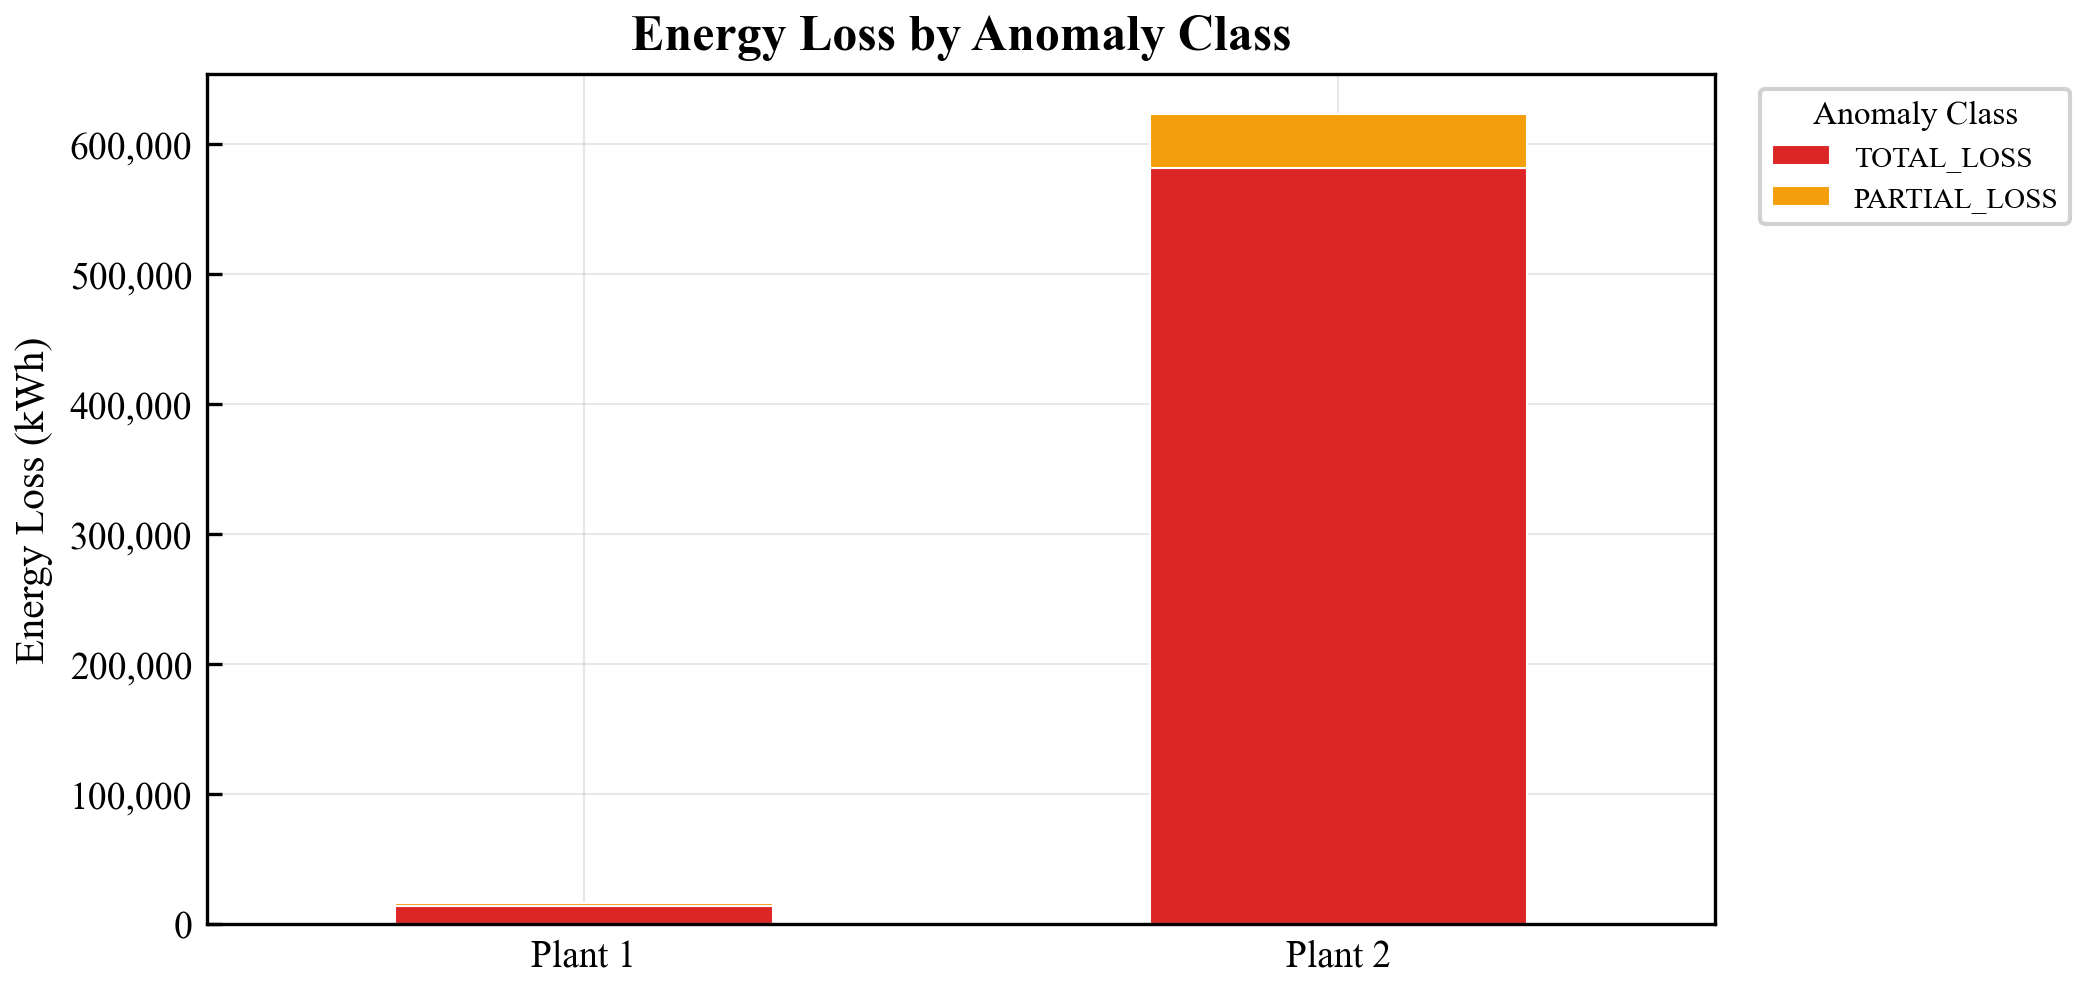

In [14]:
# === Fig 14: Energy Loss by Anomaly Class (Stacked Bar) ===

# Aggregate energy loss by anomaly class and plant
class_loss = day[day['ANOMALY_BINARY'] == 1].groupby(['PLANT_NAME', 'ANOMALY_CLASS'])['ENERGY_LOSS_KWH'].sum().reset_index()

fig, ax = plt.subplots(figsize=dual_column_figsize(3.5))

# Pivot for stacked bar
pivot = class_loss.pivot_table(index='PLANT_NAME', columns='ANOMALY_CLASS', values='ENERGY_LOSS_KWH', fill_value=0)

# Order columns by total
col_order = pivot.sum().sort_values(ascending=False).index
pivot = pivot[col_order]

colors_ordered = [ANOMALY_COLORS.get(c, '#999999') for c in col_order]
pivot.plot(kind='bar', stacked=True, ax=ax, color=colors_ordered, edgecolor='white', linewidth=0.5)

ax.set_ylabel('Energy Loss (kWh)')
ax.set_xlabel('')
ax.set_title('Energy Loss by Anomaly Class', fontsize=12, fontweight='bold')
ax.legend(title='Anomaly Class', fontsize=7, title_fontsize=8, bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=0)
format_thousands(ax)

plt.tight_layout()
save_fig(fig, 'fig_14_energy_loss_by_class')
plt.show()

In [15]:
# === Save final summary CSVs ===

inv_loss.to_csv(os.path.join(PROJECT_ROOT, 'data', 'processed', 'paper', 'carbon_loss_summary.csv'), index=False)
plant_summary.to_csv(os.path.join(PROJECT_ROOT, 'data', 'processed', 'paper', 'plant_level_summary.csv'), index=False)

print('Carbon loss summary saved.')
print(f'\n=== FINAL TOTALS ===')
print(f'Total energy generated: {day["ENERGY_KWH_INTERVAL"].sum():,.2f} kWh')
print(f'Total CO₂ avoided:     {day["CO2_AVOIDED_KG"].sum():,.2f} kg ({day["CO2_AVOIDED_KG"].sum()/1000:,.2f} tonnes)')
print(f"Total energy loss:      {day['TRUE_ENERGY_LOSS_KWH'].sum():,.2f} kWh")
print(f"Total CO₂ loss:         {day['TRUE_CO2_LOSS_KG'].sum():,.2f} kg ({day['TRUE_CO2_LOSS_KG'].sum()/1000:,.2f} tonnes)")
print(f'Emission Factor:        {EMISSION_FACTOR} kgCO₂/kWh (CEA FY2020-21)')

Carbon loss summary saved.

=== FINAL TOTALS ===
Total energy generated: 9,375,289.88 kWh
Total CO₂ avoided:     6,590,828.79 kg (6,590.83 tonnes)
Total energy loss:      639,306.10 kWh
Total CO₂ loss:         449,432.19 kg (449.43 tonnes)
Emission Factor:        0.703 kgCO₂/kWh (CEA FY2020-21)


## 4. Summary

### Key outputs from this notebook:

| Output | Description |
|---|---|
| **Fig 9** | SHAP feature importance for anomaly detection |
| **Fig 10** | SHAP beeswarm for anomaly detection |
| **Fig 11** | Case Study 1: `bvBOhCH3iADSZry` timeline + SHAP waterfall |
| **Fig 12** | Case Study 2: Worst Plant 2 inverter timeline + SHAP waterfall |
| **Fig 13** | Case Study 3: Healthy inverter (control) timeline + SHAP waterfall |
| **Fig 14** | Energy loss by anomaly class (stacked bar) |
| **Table V** | Per-inverter energy & carbon loss (top 10) |
| **Table VI** | Plant-level carbon summary |
| **carbon_loss_summary.csv** | Full per-inverter loss data |

### Carbon Methodology Disclaimer
> The carbon footprint estimation is based on the average Indian Grid Emission Factor (0.703 kgCO₂/kWh) published by the Central Electricity Authority (CEA) for FY2020–21. Actual avoided emissions may vary depending on regional grid mix, temporal changes in grid carbon intensity, and future decarbonization of the electricity system.